In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

df = sns.load_dataset("titanic")
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)

Shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dtypes:
 survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [3]:
print("Null counts per column:\n", df.isna().sum())
print("\nUnique value counts per column:\n", df.nunique())

Null counts per column:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Unique value counts per column:
 survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


## Dataset: Titanic

**Source:** Originally from the [Kaggle Titanic competition](https://www.kaggle.com/c/titanic/data),
loaded here via `seaborn.load_dataset("titanic")`, which provides the same passenger data.

**License:** Public domain / CC0 (Kaggle's Titanic dataset is freely available for
educational use).

**Why I chose it:** It's a well-documented dataset with a clear mix of numeric columns
(age, fare, sibsp, parch) and categorical columns (sex, class, embarked, who), over
200 rows, and a natural target variable (survived) that supports meaningful groupby
and feature engineering work.

In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 107


In [5]:
# 'age' has missing values -> impute with median (robust to outliers, keeps row count for analysis)
df["age"] = df["age"].fillna(df["age"].median())

# 'embarked' and 'embark_town' have very few missing values -> drop those rows
# rather than guessing a port, since it's a small number of rows
df = df.dropna(subset=["embarked", "embark_town"])

# 'deck' is missing for the majority of passengers -> too sparse to impute meaningfully,
# so we drop the column entirely rather than fabricate values
df = df.drop(columns=["deck"])

print("Shape after cleaning:", df.shape)
print("\nRemaining nulls:\n", df.isna().sum())

Shape after cleaning: (889, 14)

Remaining nulls:
 survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [6]:
# Confirm dtypes look correct after cleaning (no dates-as-strings issue here,
# but worth checking categorical columns are stored efficiently)
print(df.dtypes)

# Convert clearly categorical columns to the 'category' dtype for efficiency and clarity
categorical_cols = ["sex", "class", "who", "embarked", "embark_town", "alive"]
for col in categorical_cols:
    df[col] = df[col].astype("category")

print("\nDtypes after conversion:\n", df.dtypes)

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
embark_town         str
alive               str
alone              bool
dtype: object

Dtypes after conversion:
 survived          int64
pclass            int64
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who            category
adult_male         bool
embark_town    category
alive          category
alone              bool
dtype: object


In [7]:
print("Shape before groupby merge:", df.shape)

# For each passenger class, compute average fare and average age
# -> useful because it lets us compare each passenger's fare/age against
#    their class's typical values (e.g. did they pay more than average for their class?)
class_stats = df.groupby("class", observed=True).agg(
    class_avg_fare=("fare", "mean"),
    class_avg_age=("age", "mean")
).reset_index()

df = df.merge(class_stats, on="class", how="left")

print("Shape after groupby merge:", df.shape)
df[["class", "fare", "class_avg_fare", "age", "class_avg_age"]].head()

Shape before groupby merge: (889, 14)
Shape after groupby merge: (889, 16)


,class,fare,class_avg_fare,age,class_avg_age
0,Third,7.2500,13.675550,22.0,25.932627
1,First,71.2833,84.193516,38.0,36.688879
2,Third,7.9250,13.675550,26.0,25.932627
3,First,53.1000,84.193516,35.0,36.688879
4,Third,8.0500,13.675550,35.0,25.932627


In [8]:
print("Shape before pivot:", df.shape)

# Pivot: survival rate by sex and class -> answers "did survival depend on
# both gender and class together, not just one factor alone?"
survival_pivot = df.pivot_table(
    values="survived",
    index="sex",
    columns="class",
    aggfunc="mean",
    observed=True
)

print("Shape after pivot (this is a separate summary table, not merged back):", df.shape)
survival_pivot

Shape before pivot: (889, 16)
Shape after pivot (this is a separate summary table, not merged back): (889, 16)


class,First,Second,Third
sex,,,
female,0.967391,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [9]:
# Convert 'fare' to a NumPy array and compute a z-score (standardized fare)
# using vectorized broadcasting -- no explicit Python loop needed
fare_array = df["fare"].to_numpy()

fare_mean = fare_array.mean()
fare_std = fare_array.std()

fare_zscore = (fare_array - fare_mean) / fare_std  # broadcasting subtracts/divides element-wise

print("Mean:", fare_zscore.mean())
print("Std:", fare_zscore.std())
print("Min:", fare_zscore.min())
print("Max:", fare_zscore.max())

df["fare_zscore"] = fare_zscore
df[["fare", "fare_zscore"]].head()

Mean: 1.3987061727561027e-16
Std: 1.0
Min: -0.6462044460638905
Max: 9.668550782149426


,fare,fare_zscore
0,7.2500,-0.500240
1,71.2833,0.788947
2,7.9250,-0.486650
3,53.1000,0.422861
4,8.0500,-0.484133


In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

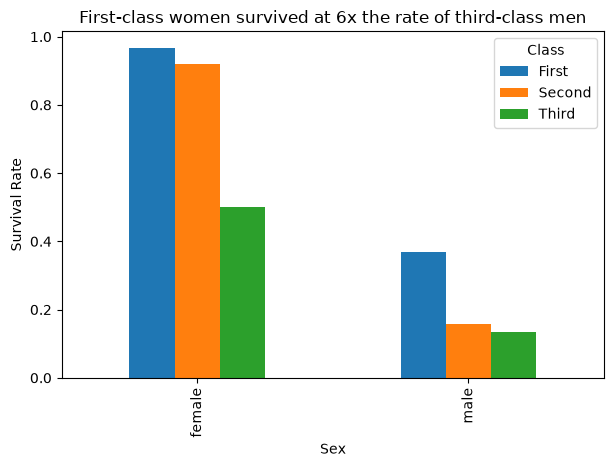

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))

survival_pivot.plot(kind="bar", ax=ax)

ax.set_xlabel("Sex")
ax.set_ylabel("Survival Rate")
ax.set_title("First-class women survived at 6x the rate of third-class men")
ax.legend(title="Class")

plt.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

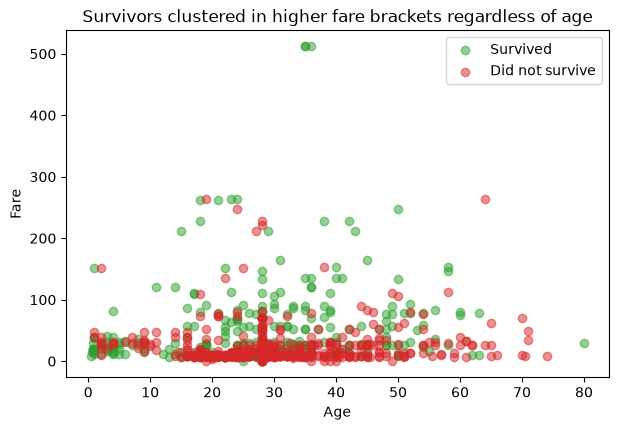

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))

survived = df[df["survived"] == 1]
died = df[df["survived"] == 0]

ax.scatter(survived["age"], survived["fare"], alpha=0.5, label="Survived", color="tab:green")
ax.scatter(died["age"], died["fare"], alpha=0.5, label="Did not survive", color="tab:red")

ax.set_xlabel("Age")
ax.set_ylabel("Fare")
ax.set_title("Survivors clustered in higher fare brackets regardless of age")
ax.legend()

plt.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
df.to_csv("../data/processed/titanic_cleaned.csv", index=False)
print("Saved to data/processed/titanic_cleaned.csv")
print("Final shape:", df.shape)

Saved to data/processed/titanic_cleaned.csv
Final shape: (889, 17)
